Day 12 — Logistic Regression on a Real Dataset

Goal: apply logistic regression with a full evaluation pipeline (accuracy, precision, recall, F1, confusion matrix).

1) Dataset (synthetic but realistic)

We’ll classify emails as spam (1) or not spam (0) using two features:

word_freq (keyword frequency)
email_length
import numpy as np

# Features: [word_freq, email_length]
X = np.array([
    [5, 100],
    [7, 120],
    [10, 150],
    [3, 90],
    [1, 60],
    [2, 70],
    [8, 130],
    [6, 110],
    [9, 140],
    [4, 95]
], dtype=float)

# Labels: 1 = spam, 0 = not spam
y = np.array([1,1,1,0,0,0,1,1,1,0])
2) Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
3) Feature Scaling (important for logistic regression)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
4) Train Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)
5) Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]  # probability of class 1
6) Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
7) Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Interpretation:

[[TN  FP]
 [FN  TP]]
8) Visualizing Confusion Matrix
import matplotlib.pyplot as plt

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

labels = ["0", "1"]
plt.xticks([0,1], labels)
plt.yticks([0,1], labels)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i][j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Accuracy:  0.75
Precision:  0.6666666666666666
Recall:  1.0
F1 Score:  0.8
Accuracy T:  0.75
Precision T:  1.0
Recall T:  0.5
F1 Score T:  0.6666666666666666
Confusion Matrix:
 [[1 1]
 [0 2]]
Confusion Matrix T:
 [[2 0]
 [1 1]]


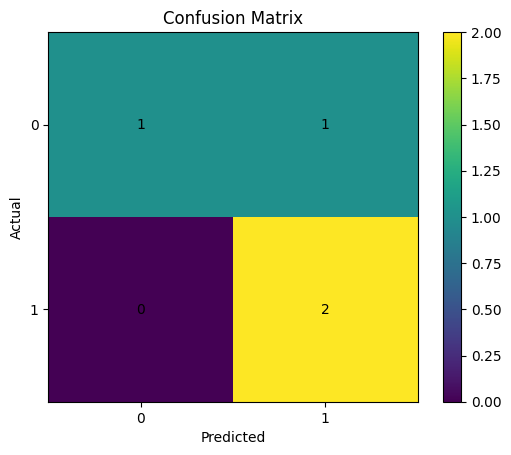

In [13]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

X = np.array([
    [5, 100],
    [7, 120],
    [10, 150],
    [3, 90],
    [1, 60],
    [2, 70],
    [8, 130],
    [6, 110],
    [9, 140],
    [4, 95],
    [5,85],
    [6,95],
    [7,105]  
], dtype=float)

y = np.array([1,1,1,0,0,0,1,1,1,0,0,0,1])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

threshold = 0.7
y_pred_threshold = (y_prob >= threshold).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy: ",accuracy)
print("Precision: ",precision)
print("Recall: ",recall)   
print("F1 Score: ",f1)

accuracy_t = accuracy_score(y_test, y_pred_threshold)
precision_t = precision_score(y_test, y_pred_threshold)
recall_t = recall_score(y_test, y_pred_threshold)
f1_t = f1_score(y_test, y_pred_threshold)

print("Accuracy T: ",accuracy_t)
print("Precision T: ",precision_t)
print("Recall T: ",recall_t)   
print("F1 Score T: ",f1_t)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

cm_t = confusion_matrix(y_test, y_pred_threshold)
print("Confusion Matrix T:\n", cm_t)

plt.imshow(cm)
plt.title('Confusion Matrix')
plt.colorbar()

labels = ["0","1"]
plt.xticks([0,1], labels)
plt.yticks([0,1], labels)   

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show() 



Accuracy:  1.0
Precision:  1.0
Recall:  1.0
F1 Score:  1.0
Confusion Matrix:
 [[1 0] [TN FP]
 [0 2]] [FN TP]



 1. false positive
 2. FP -> when model marks as false entity as true then it is false positive

 FN -> when model misses the entity then it is marked as false negative
 3. the model is more biased to class 1.
 4. Accuracy is a common metric for evaluating classification models, but it may not always be sufficient, especially in cases where the classes are imbalanced. In such cases, a model could achieve high accuracy by simply predicting the majority class, while performing poorly on the minority class.
In addition to accuracy, it is important to consider other metrics such as precision, recall, and f1 score


Accuracy:  0.75
Precision:  0.6666666666666666
Recall:  1.0
F1 Score:  0.8
Confusion Matrix:
 [[1 1]
 [0 2]]

 1. false positive
 2. tn - 1, fp - 1, fn - 0, tp - 2, yes the model is biased
 3. i will improve the dataset for better accuracy of the model


 